# Decision Trees — Machine Learning Project

In this project, we use the **Titanic dataset** to predict passenger survival using a Decision Tree classifier.

**What we'll cover:**
- Exploratory Data Analysis (EDA)
- Data Preprocessing
- How Decision Trees work (Entropy, Gini, Information Gain)
- Training & Evaluation
- Overfitting vs. Underfitting (Learning Curves)
- Gini vs. Entropy Comparison
- Hyperparameter Tuning (GridSearchCV)
- Prediction Example

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

warnings.filterwarnings('ignore')
sns.set(style='whitegrid')
%matplotlib inline

## 2. Dataset

The **Titanic dataset** contains passenger information. Our goal is to predict if a passenger **survived (1)** or **didn't survive (0)**.

| Feature | Description |
|---|---|
| pclass | Passenger class (1st, 2nd, 3rd) |
| sex | Gender |
| age | Age |
| sibsp | Siblings/spouses aboard |
| parch | Parents/children aboard |
| fare | Ticket price |
| embarked | Port of embarkation |
| **survived** | **Target: 1 = survived, 0 = didn't** |

In [2]:
# Load Titanic dataset
titanic = sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Basic info and missing values
print(titanic.info())
print("\nMissing values:\n", titanic.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
None

Missing values:
 survived         0
pclass           0
sex              0
age           

## 3. Exploratory Data Analysis (EDA)

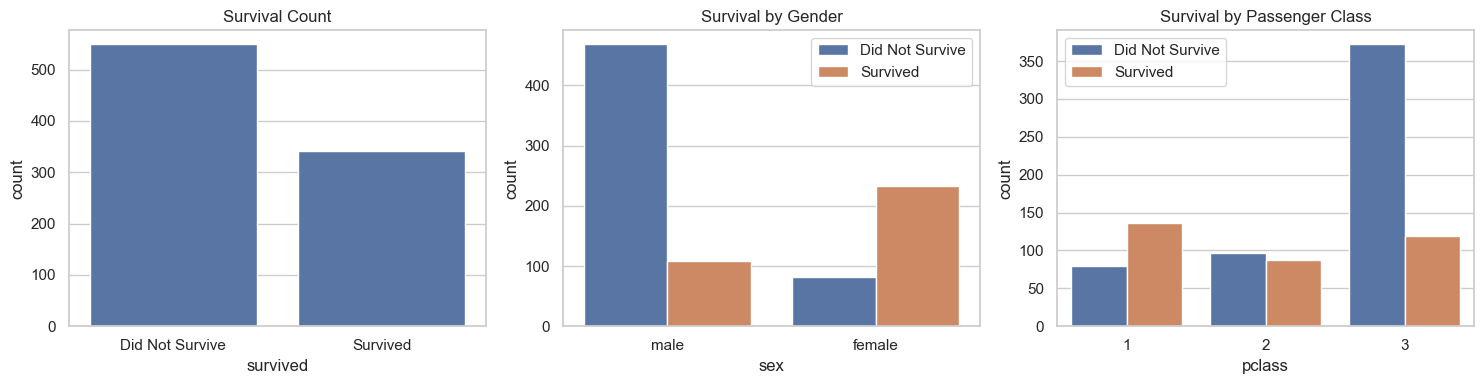

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Survival count
sns.countplot(x='survived', data=titanic, ax=axes[0])
axes[0].set_title('Survival Count')
axes[0].set_xticklabels(['Did Not Survive', 'Survived'])

# Survival by gender
sns.countplot(x='sex', hue='survived', data=titanic, ax=axes[1])
axes[1].set_title('Survival by Gender')
axes[1].legend(['Did Not Survive', 'Survived'])

# Survival by class
sns.countplot(x='pclass', hue='survived', data=titanic, ax=axes[2])
axes[2].set_title('Survival by Passenger Class')
axes[2].legend(['Did Not Survive', 'Survived'])

plt.tight_layout()
plt.show()

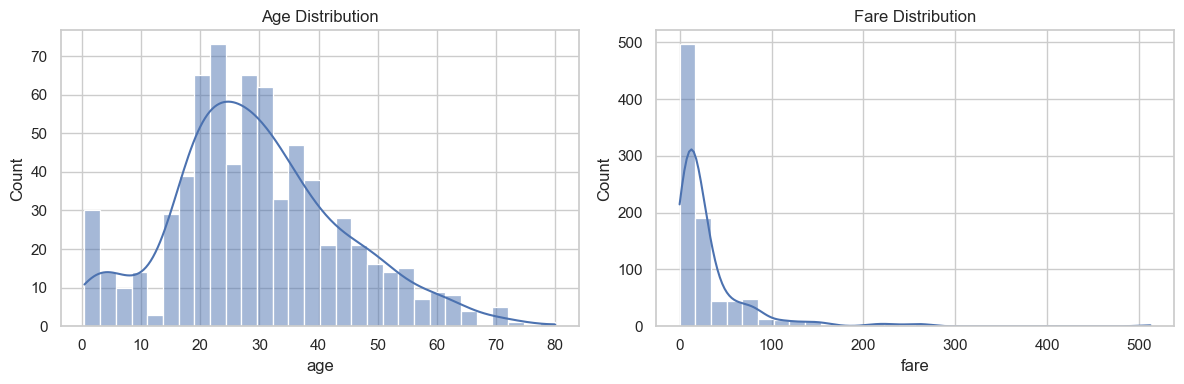

In [5]:
# Age and fare distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(titanic['age'].dropna(), kde=True, bins=30, ax=axes[0])
axes[0].set_title('Age Distribution')

sns.histplot(titanic['fare'], kde=True, bins=30, ax=axes[1])
axes[1].set_title('Fare Distribution')

plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [6]:
# Select relevant columns
columns_to_use = ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
data = titanic[columns_to_use].copy()

# Fill missing values
data['age'].fillna(data['age'].median(), inplace=True)        # Use median for age
data['embarked'].fillna(data['embarked'].mode()[0], inplace=True)  # Use most frequent port

# Convert categorical columns to numbers (one-hot encoding)
data_encoded = pd.get_dummies(data, columns=['sex', 'embarked'], drop_first=True)

data_encoded.head()

,survived,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [7]:
# Split into features (X) and target (y)
X = data_encoded.drop('survived', axis=1)
y = data_encoded['survived']

# 70% training, 30% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print('Training set size:', X_train.shape)
print('Testing set  size:', X_test.shape)

Training set size: (623, 8)
Testing set  size: (268, 8)


## 5. Train the Model

In [8]:
# Train a basic Decision Tree (default settings)
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Evaluate on test set
y_pred = dt.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred))

Accuracy: 0.746268656716418

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.81      0.79       157
           1       0.71      0.66      0.68       111

    accuracy                           0.75       268
   macro avg       0.74      0.73      0.74       268
weighted avg       0.74      0.75      0.74       268



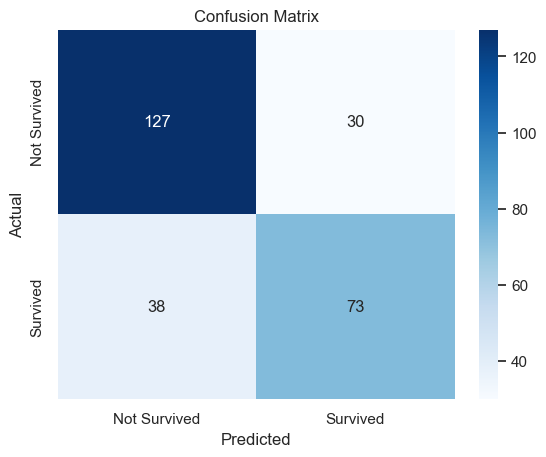

In [9]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## 6. Overfitting vs. Underfitting

- **Underfitting**: The model is too simple — it doesn't learn the data well (low train AND test accuracy).
- **Overfitting**: The model memorizes the training data — it performs well on training but poorly on new data.
- **`max_depth`** controls tree complexity. A very deep tree overfits; a very shallow tree underfits.

The plot below shows how training and test accuracy change as `max_depth` increases:

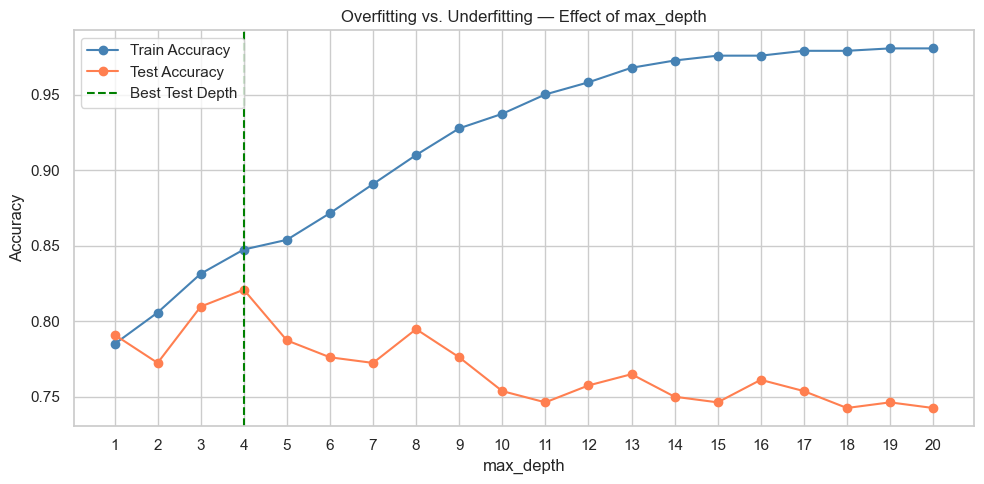

Best max_depth: 4 → Test Accuracy: 0.8209


In [10]:
# Compare train vs test accuracy for different max_depth values
depths = range(1, 21)
train_scores = []
test_scores = []

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, model.predict(X_train)))
    test_scores.append(accuracy_score(y_test, model.predict(X_test)))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(depths, train_scores, marker='o', label='Train Accuracy', color='steelblue')
plt.plot(depths, test_scores, marker='o', label='Test Accuracy', color='coral')
plt.axvline(x=test_scores.index(max(test_scores)) + 1, color='green', linestyle='--', label='Best Test Depth')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Overfitting vs. Underfitting — Effect of max_depth')
plt.legend()
plt.xticks(depths)
plt.tight_layout()
plt.show()

best_depth = test_scores.index(max(test_scores)) + 1
print(f'Best max_depth: {best_depth} → Test Accuracy: {max(test_scores):.4f}')

## 7. Gini vs. Entropy Comparison

Both criteria are used to decide the best split at each node. Here we compare them visually across different tree depths:

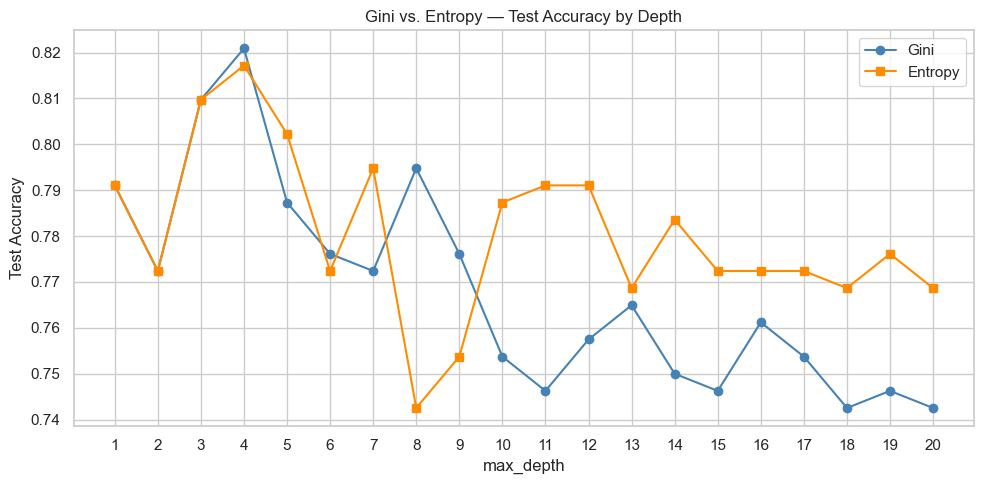

Best Gini Accuracy:    0.8209 at depth 4
Best Entropy Accuracy: 0.8172 at depth 4


In [11]:
# Compare Gini and Entropy across different depths
gini_scores = []
entropy_scores = []

for depth in depths:
    # Gini model
    gini_model = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=42)
    gini_model.fit(X_train, y_train)
    gini_scores.append(accuracy_score(y_test, gini_model.predict(X_test)))

    # Entropy model
    entropy_model = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42)
    entropy_model.fit(X_train, y_train)
    entropy_scores.append(accuracy_score(y_test, entropy_model.predict(X_test)))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(depths, gini_scores, marker='o', label='Gini', color='steelblue')
plt.plot(depths, entropy_scores, marker='s', label='Entropy', color='darkorange')
plt.xlabel('max_depth')
plt.ylabel('Test Accuracy')
plt.title('Gini vs. Entropy — Test Accuracy by Depth')
plt.legend()
plt.xticks(depths)
plt.tight_layout()
plt.show()

print(f'Best Gini Accuracy:    {max(gini_scores):.4f} at depth {gini_scores.index(max(gini_scores)) + 1}')
print(f'Best Entropy Accuracy: {max(entropy_scores):.4f} at depth {entropy_scores.index(max(entropy_scores)) + 1}')

## 8. Hyperparameter Tuning (GridSearchCV)

Instead of manually testing each combination, **GridSearchCV** tries all combinations and picks the best one using cross-validation.

In [12]:
# Define the parameter grid to search
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Run grid search with 5-fold cross-validation
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print('Best Parameters:              ', grid_search.best_params_)
print('Best Cross-Validation Accuracy:', round(grid_search.best_score_, 4))

Best Parameters:               {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}
Best Cross-Validation Accuracy: 0.8106


In [13]:
# Evaluate the best model on the test set
best_dt = grid_search.best_estimator_
y_pred_best = best_dt.predict(X_test)

print('Test Accuracy (Best Model):', round(accuracy_score(y_test, y_pred_best), 4))
print('\nClassification Report:\n', classification_report(y_test, y_pred_best))

Test Accuracy (Best Model): 0.8097

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.89      0.84       157
           1       0.81      0.70      0.75       111

    accuracy                           0.81       268
   macro avg       0.81      0.79      0.80       268
weighted avg       0.81      0.81      0.81       268



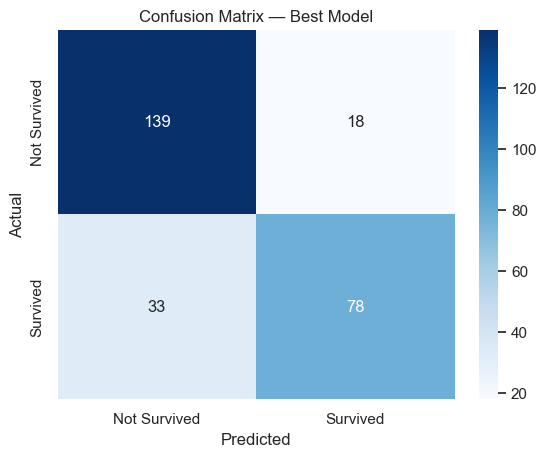

In [14]:
# Confusion matrix for best model
cm_best = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.title('Confusion Matrix — Best Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## 9. Visualize the Best Decision Tree

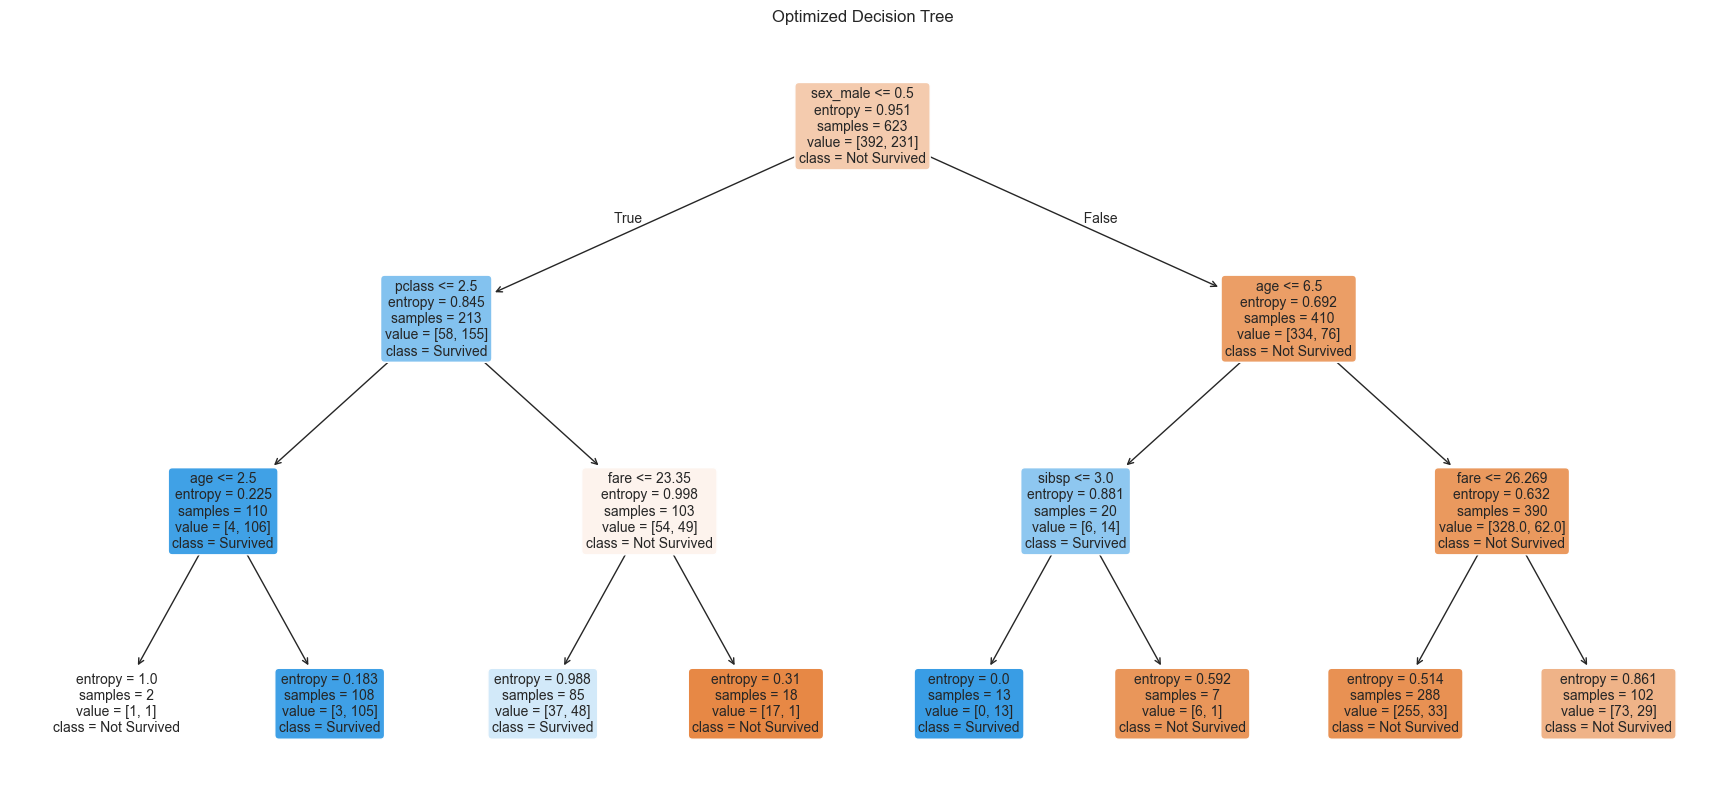

In [15]:
# Plot the optimized decision tree
plt.figure(figsize=(22, 10))
plot_tree(best_dt,
          feature_names=X.columns,
          class_names=['Not Survived', 'Survived'],
          filled=True, rounded=True, fontsize=10)
plt.title('Optimized Decision Tree')
plt.show()

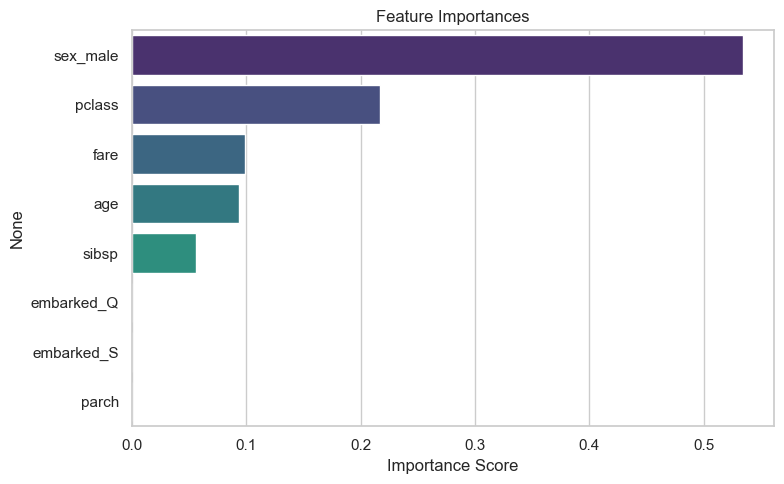

In [16]:
# Feature importances — which features mattered most?
importances = best_dt.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 5))
sns.barplot(x=importances[indices], y=X.columns[indices], palette='viridis')
plt.title('Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 10. Prediction Example

Let's predict survival for a new passenger step by step.

**Passenger profile:**
- 3rd class, male, 23 years old
- 1 sibling aboard, no parents/children
- Fare: £6.25
- Embarked from Queenstown (Q)

In [17]:
# Build the passenger input
# Columns: pclass, age, sibsp, parch, fare, sex_male, embarked_Q, embarked_S
new_passenger = pd.DataFrame([{
    'pclass': 3,
    'age': 23.0,
    'sibsp': 1,
    'parch': 0,
    'fare': 6.25,
    'sex_male': True,    # Male → True
    'embarked_Q': True,  # Queenstown → True
    'embarked_S': False
}])

# Make prediction
prediction = best_dt.predict(new_passenger)[0]
probability = best_dt.predict_proba(new_passenger)[0]

# Display the result
print('=== Passenger Prediction ===')
print(f'Survival Prediction : {"Survived" if prediction == 1 else "Did Not Survive"}')
print(f'Probability Not Survived : {probability[0]:.2%}')
print(f'Probability Survived     : {probability[1]:.2%}')

=== Passenger Prediction ===
Survival Prediction : Did Not Survive
Probability Not Survived : 88.54%
Probability Survived     : 11.46%
